Generating synthetic data for Stress Per Pair parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy full matrix stress finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy stress_per_pair finished.

          PARITY VALIDATION
MSE on Pairwise Stress Matrix : 0.000000e+00

SUCCESS: DimRedPy Pairwise Stress perfectly matches rigorous SciPy reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_analysis\verify_parity_analysis_stress_per_pair_plot.png


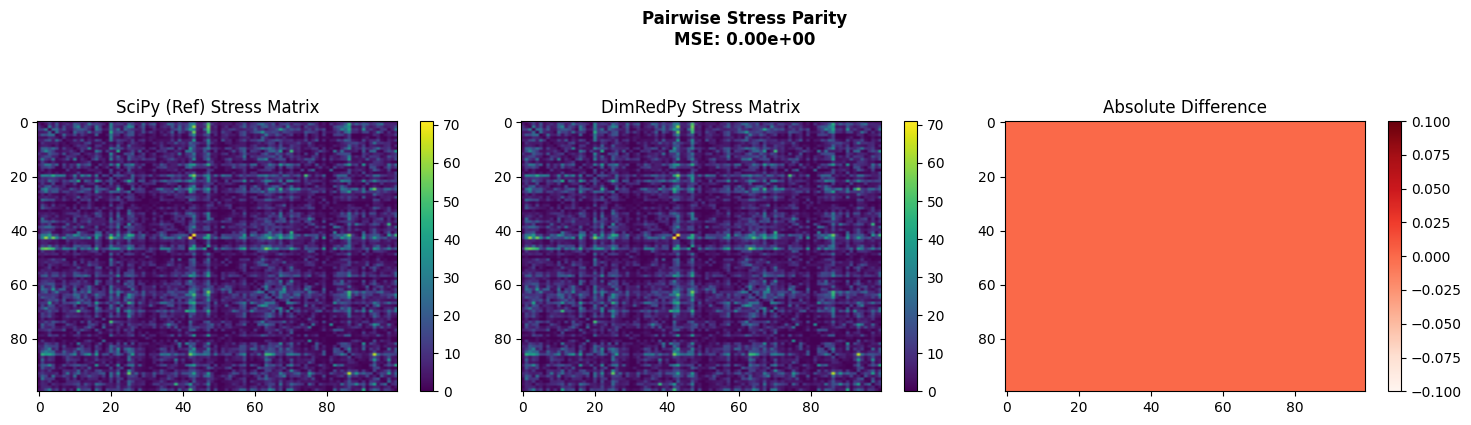

In [1]:
"""
Rigorous Verification of Analysis Parity: Pairwise Stress Matrix
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.analysis import stress_per_pair

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic data for Stress Per Pair parity...")
np.random.seed(42)
N = 100
# High-dimensional data
landmarks_hd = np.random.randn(N, 10)
# Low-dimensional data
landmarks_ld = np.random.randn(N, 2)
# Random weights
weights = np.random.uniform(0.5, 1.5, size=N)

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy exact cdist matrix & outer product)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Exact full distance matrices using SciPy
ref_hd_mat = cdist(landmarks_hd, landmarks_hd, metric='euclidean')
ref_ld_mat = cdist(landmarks_ld, landmarks_ld, metric='euclidean')

# Weight outer product
W = np.outer(weights, weights)

# Exact pairwise stress
ref_stress_mat = W * (ref_hd_mat - ref_ld_mat)**2

print("-> SciPy full matrix stress finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

dimred_stress_mat = stress_per_pair(landmarks_hd, landmarks_ld, weights=weights)

print("-> DimRedPy stress_per_pair finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = np.mean((ref_stress_mat - dimred_stress_mat) ** 2)

print(f"MSE on Pairwise Stress Matrix : {mse:.6e}")

if mse < 1e-10:
    print("\nSUCCESS: DimRedPy Pairwise Stress perfectly matches rigorous SciPy reference.")
else:
    print("\nFAILURE: Statistical divergence detected in pairwise stress parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
fig.suptitle(f"Pairwise Stress Parity\nMSE: {mse:.2e}", fontweight='bold', y=1.05)

vmax = np.max(ref_stress_mat)

im0 = axes[0].imshow(ref_stress_mat, aspect='auto', cmap='viridis', vmax=vmax)
axes[0].set_title("SciPy (Ref) Stress Matrix")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dimred_stress_mat, aspect='auto', cmap='viridis', vmax=vmax)
axes[1].set_title("DimRedPy Stress Matrix")
fig.colorbar(im1, ax=axes[1])

diff = np.abs(ref_stress_mat - dimred_stress_mat)
im2 = axes[2].imshow(diff, aspect='auto', cmap='Reds')
axes[2].set_title("Absolute Difference")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_analysis_stress_per_pair_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
